# Проверка данных

Для анализа использовались данные о количестве онлайн пользователей в одной из игр.

In [24]:
import warnings


from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.tsa.api as smt
import statsmodels.api as sm
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

import tensorflow as tf

warnings.filterwarnings('ignore')

In [4]:
def plotly_df(df, title = ''):
    for col in df.columns:
        plt.plot(df.index,df[col], label=col)

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')
    plt.show()

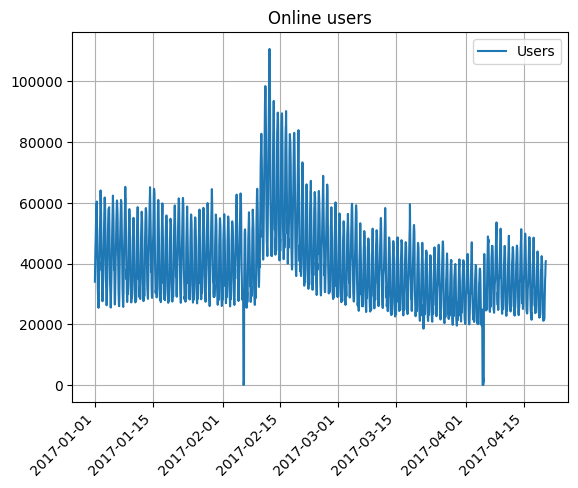

In [5]:
dataset = pd.read_csv('hour_online.csv', index_col=['Time'], parse_dates=['Time'])
plotly_df(dataset, title = "Online users")

In [6]:
def plotMovingAverage(series, n):
    """
    series - dataframe with timeseries
    n - rolling window size
    """
    rolling_mean = series.rolling(window=n).mean()
    rolling_std =  series.rolling(window=n).std()
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
    plt.plot(lower_bond, "r--")
    plt.plot(dataset[n:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

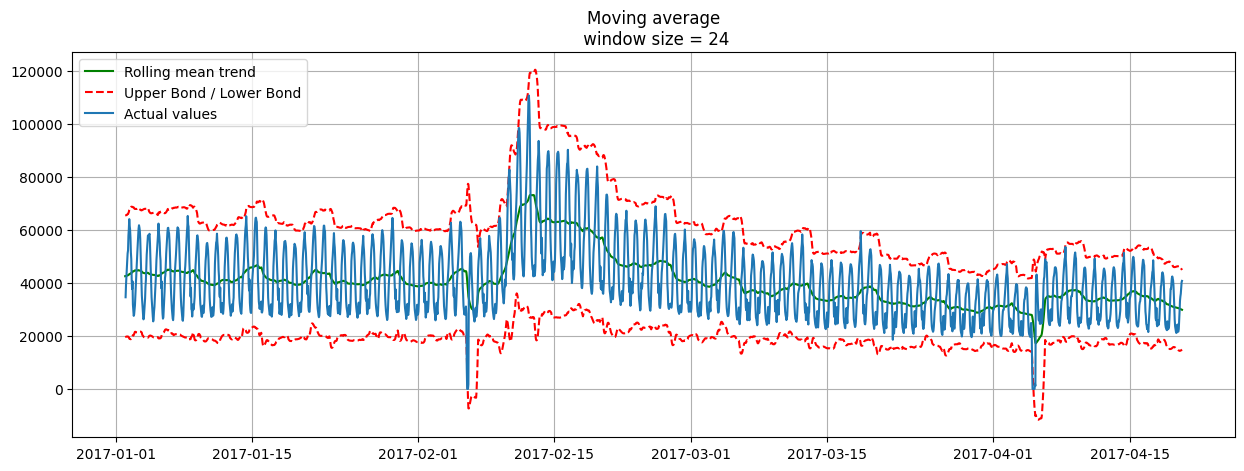

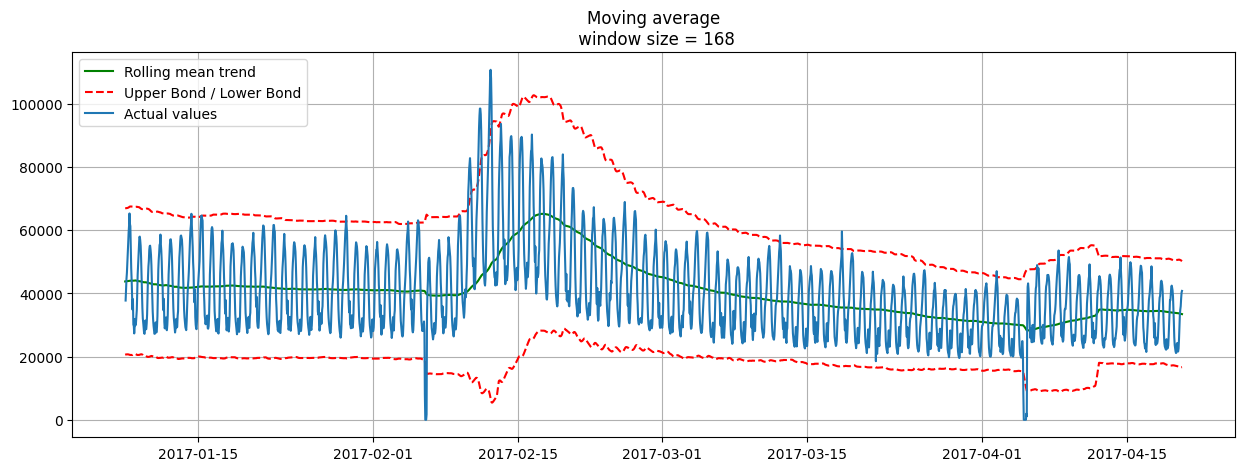

In [7]:
plotMovingAverage(dataset, 24)
plotMovingAverage(dataset, 24*7)

Из графиков видно, что есть прирост игроков каждую неделю по выходным. А так же заметна общая тенденция, рост в феврале и дальше спад.

Критерий Дики-Фуллера: p=0.190189


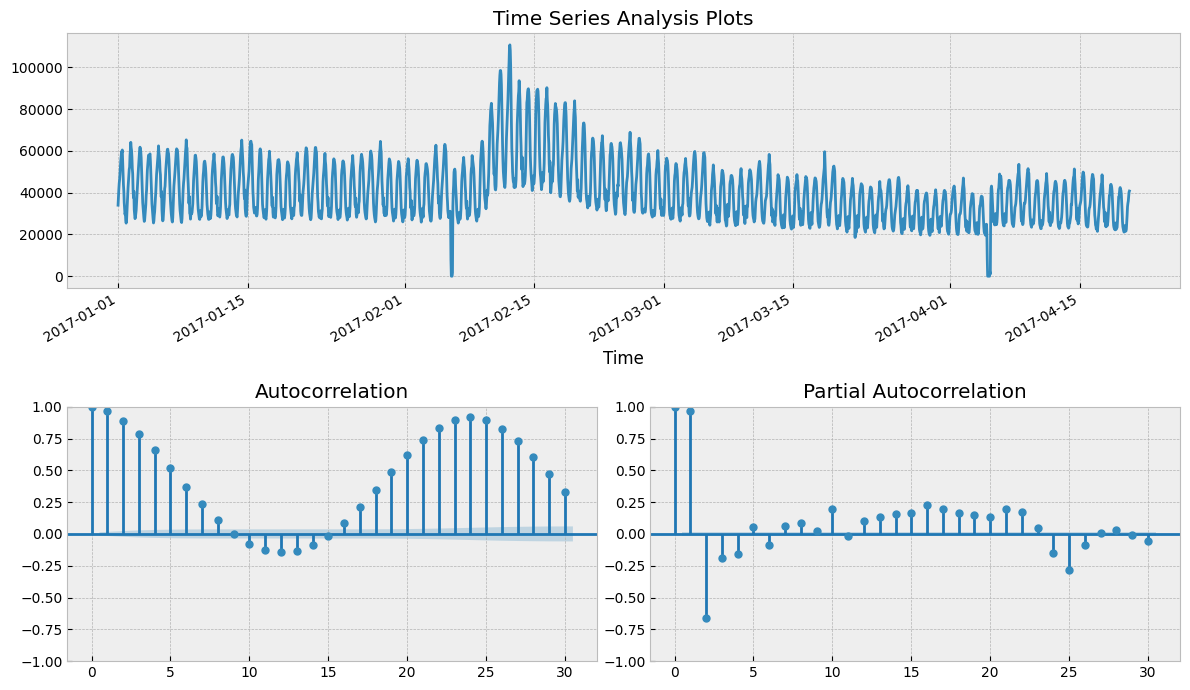

In [8]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Time Series Analysis Plots')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

        print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(y)[1])

        plt.tight_layout()
    return

tsplot(dataset.Users, lags=30)

 Исходный ряд стационарным не является, критерий Дики-Фуллера не отверг нулевую гипотезу о наличии единичного корня.

Критерий Дики-Фуллера: p=0.000000


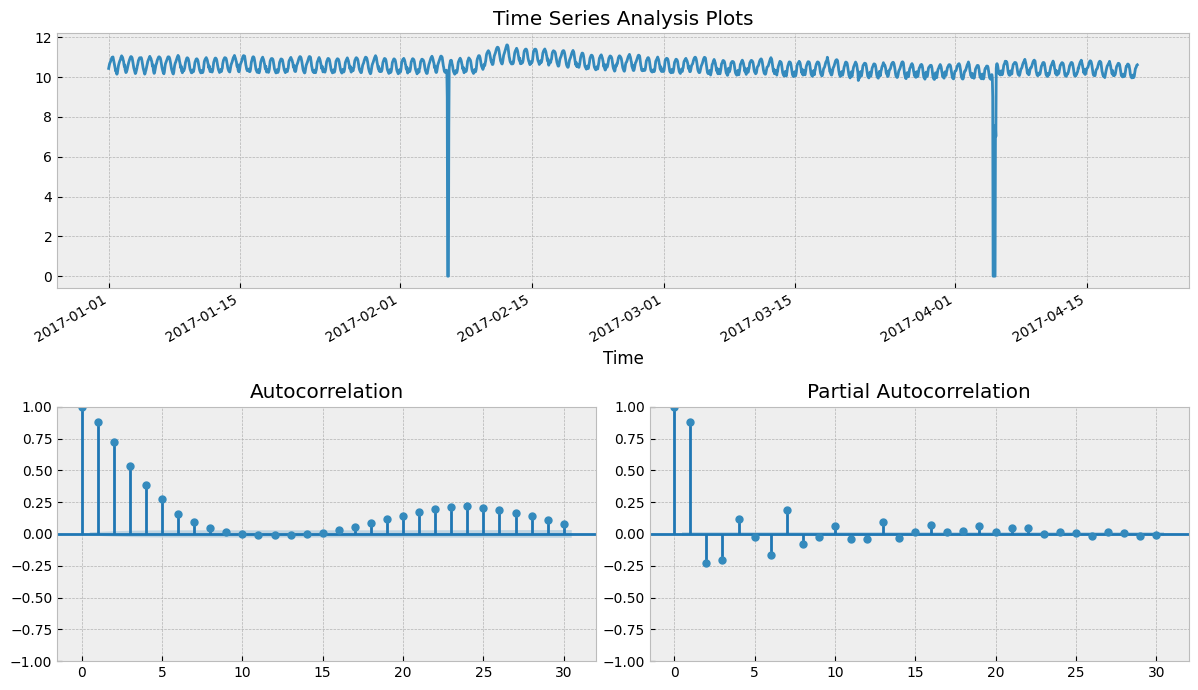

In [9]:
data = dataset.copy()
data["Users_log"] = np.log1p(data["Users"])
tsplot(data.Users_log, lags=30)

Критерий Дики-Фуллера отвергает нулевую гипотезу о нестационарности, но автокорреляционная функция всё ещё выглядит нехорошо из-за большого числа значимых лагов.

Критерий Дики-Фуллера: p=0.000000


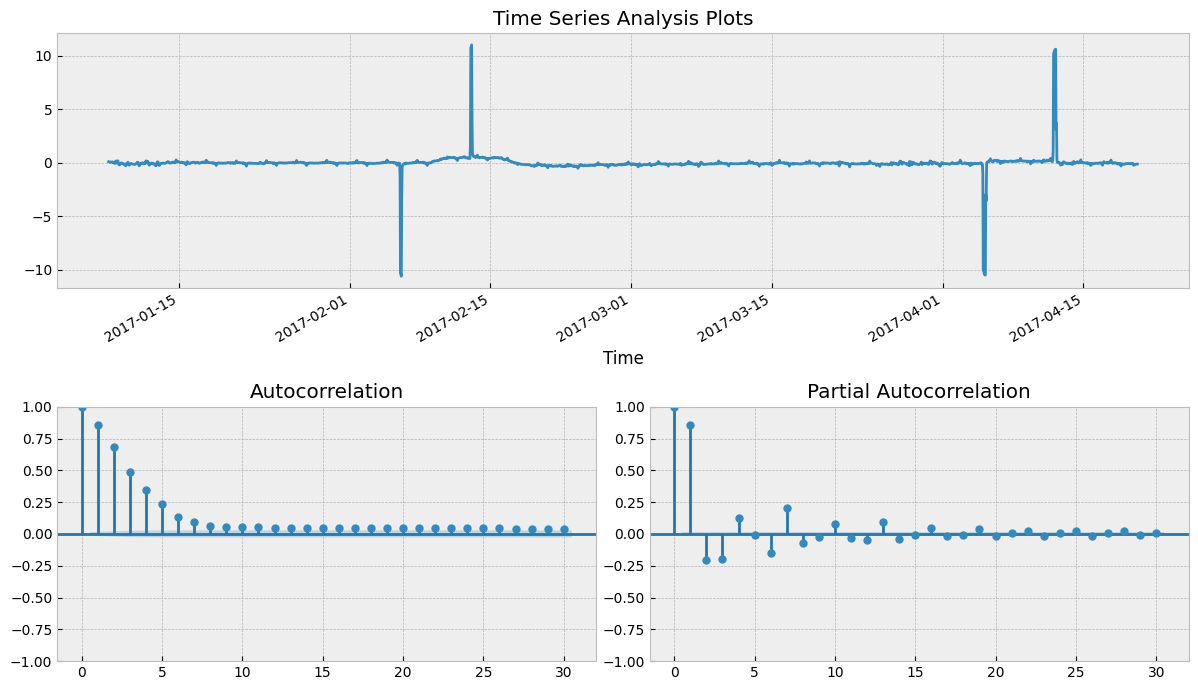

In [10]:
data['Users_log_season'] = data.Users_log - data.Users_log.shift(24*7)
tsplot(data.Users_log_season[24*7:], lags=30)

На графике частной автокорреляционной функции значим лишь один лаг, стоит взять еще первые разности, чтобы привести наконец ряд к стационарному виду.

Критерий Дики-Фуллера: p=0.000000


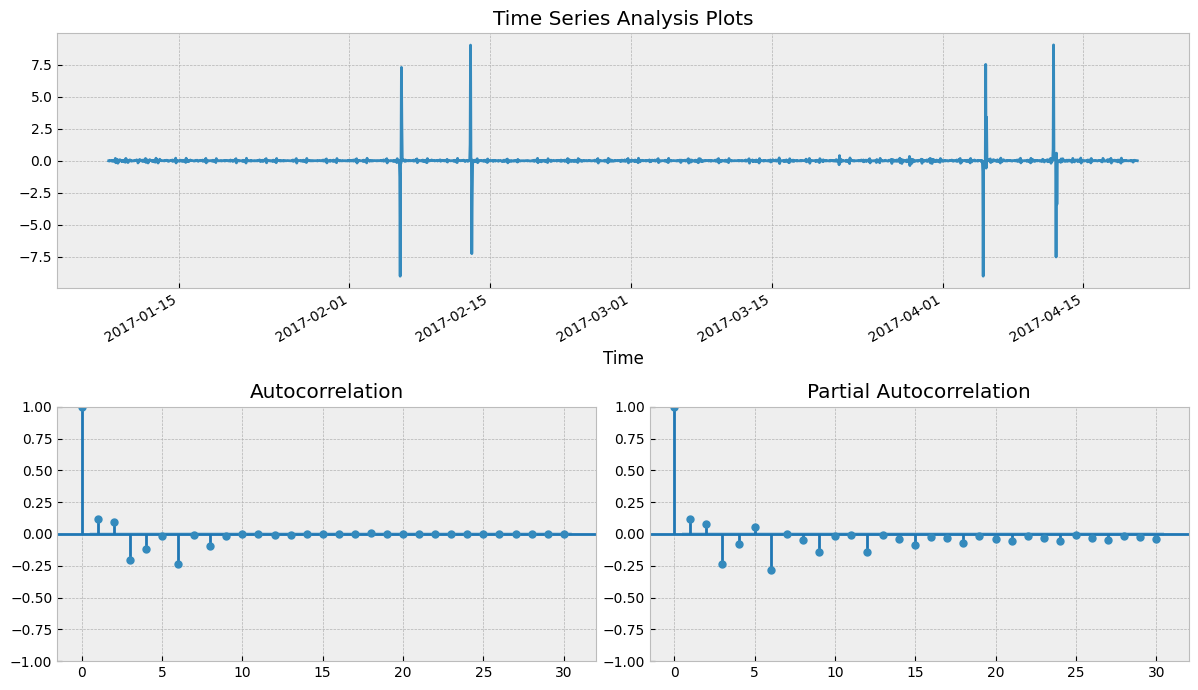

In [11]:
data['Users_log_season_diff'] = data.Users_log_season - data.Users_log_season.shift(1)
tsplot(data.Users_log_season_diff[24*7+1:], lags=30)

In [12]:
data_train = data.iloc[:-100].copy()
data_test = data.iloc[-100:].copy()

In [13]:
data_train["Users_log"] = np.log1p(data_train["Users"])
data_test["Users_log"] = np.log1p(data_test["Users"])

# ARIMA

In [14]:
ps = range(0, 5)
d=1
qs = range(0, 5)

from itertools import product

parameters = product(ps, qs)
parameters_list = list(parameters)
len(parameters_list)

25

In [15]:
results = []
best_aic = float("inf")

for param in tqdm(parameters_list):
    #try except нужен, потому что на некоторых наборах параметров модель не обучается
    try:
        model= ARIMA(data_train.Users_log, order=(param[0], d, param[1])).fit()
    #выводим параметры, на которых модель не обучается и переходим к следующему набору
    except ValueError:
        print('wrong parameters:', param)
        continue
    aic = model.aic
    #сохраняем лучшую модель, aic, параметры
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])

warnings.filterwarnings('default')

result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())


100%|██████████| 25/25 [00:26<00:00,  1.05s/it]

   parameters          aic
19     (3, 4)  1296.871220
24     (4, 4)  1297.802373
23     (4, 3)  1302.155813
18     (3, 3)  1368.673011
9      (1, 4)  1410.376264


In [16]:
best_model = ARIMA(
    data_train["Users_log"].astype(float),
    order=(best_param[0], d, best_param[1]),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
print(best_model.summary())

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Users_log   No. Observations:                 2525
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -641.887
Date:                Wed, 01 Apr 2026   AIC                           1299.774
Time:                        21:20:42   BIC                           1346.427
Sample:                             0   HQIC                          1316.704
                               - 2525                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5021      0.016    -31.695      0.000      -0.533      -0.471
ar.L2          0.3785      0.018     21.203      0.000       0.344       0.413
ar.L3          0.4378      0.012     36.734      0.0

Критерий Дики-Фуллера: p=0.000000


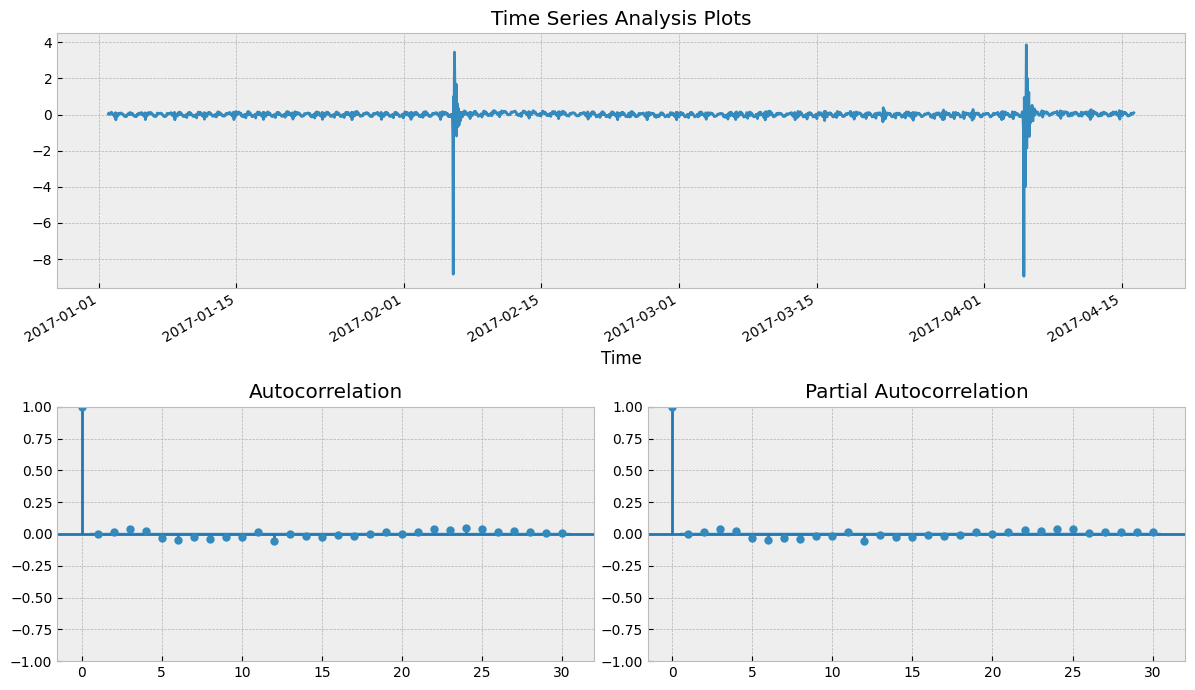

In [17]:
tsplot(best_model.resid[24:], lags=30)

In [18]:
forecast_log = best_model.forecast(steps=len(data_test))
print("NaN in forecast_log:", forecast_log.isna().sum())
print("NaN in params:", best_model.params.isna().sum())


NaN in forecast_log: 0
NaN in params: 0


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [19]:
forecast_log

2525    10.578303
2526    10.532789
2527    10.466558
2528    10.429552
2529    10.403140
          ...    
2620    10.304725
2621    10.304725
2622    10.304725
2623    10.304725
2624    10.304725
Name: predicted_mean, Length: 100, dtype: float64

In [20]:
forecast = pd.Series(
    np.expm1(forecast_log.to_numpy()),   # без индексного выравнивания
    index=data_test.index
).clip(lower=0)

In [21]:
forecast

Time
2017-04-16 06:00:00    39272.410789
2017-04-16 07:00:00    37524.992667
2017-04-16 08:00:00    35120.127262
2017-04-16 09:00:00    33844.177370
2017-04-16 10:00:00    32961.969453
                           ...     
2017-04-20 05:00:00    29872.446073
2017-04-20 06:00:00    29872.446073
2017-04-20 07:00:00    29872.446073
2017-04-20 08:00:00    29872.446073
2017-04-20 09:00:00    29872.446073
Length: 100, dtype: float64

In [22]:
mae_test = mean_absolute_error(data_test['Users'], forecast)
print(f"Test MAE: {mae_test:.2f}")

Test MAE: 7357.64


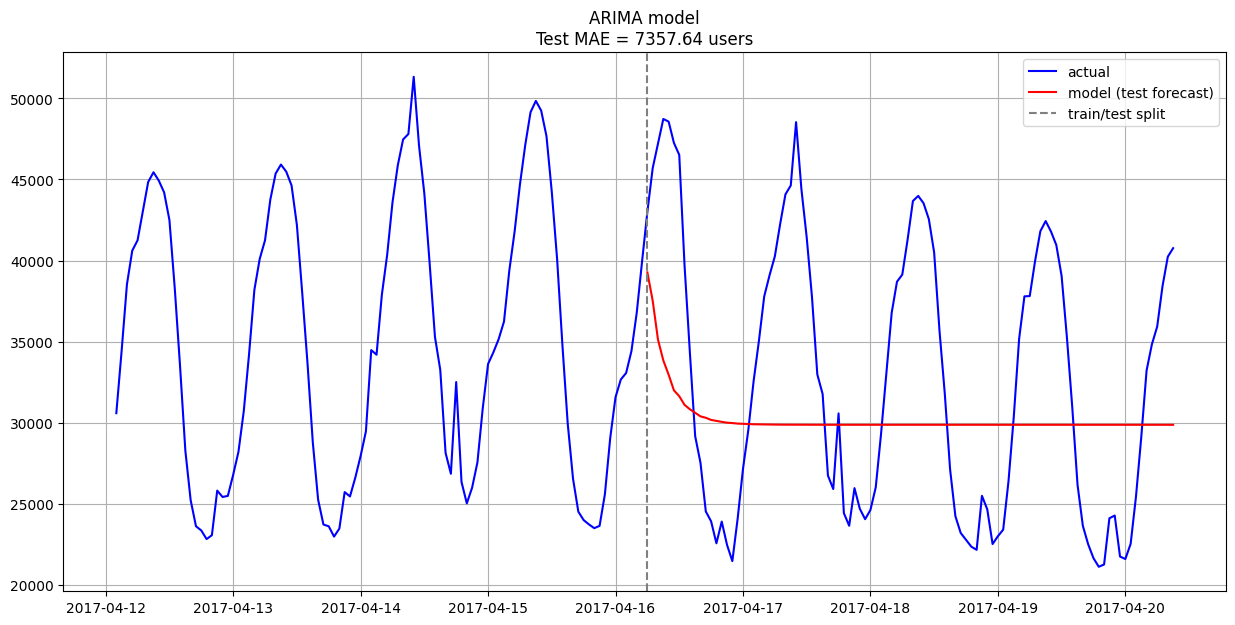

In [23]:
last_n = 200
actual_last = data['Users'].iloc[-last_n:]

# прогноз есть только на test, поэтому переиндексируем по фактическому окну
model_last = forecast.reindex(actual_last.index)

plt.figure(figsize=(15, 7))
plt.plot(actual_last, label='actual', color='blue')
plt.plot(model_last, label='model (test forecast)', color='red')

split_time = data_test.index[0]
if split_time >= actual_last.index.min():
    plt.axvline(split_time, color='gray', linestyle='--', label='train/test split')

plt.title(f"ARIMA model\nTest MAE = {mae_test:.2f} users")
plt.legend()
plt.grid(True)
plt.show()

# LSTM

In [78]:
# Функция univariate_data подготавливает данные для модели прогнозирования временных рядов.
def univariate_data(dataset, start_index, end_index, history_size, target_size):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i - history_size, i)
        data.append(np.reshape(dataset.iloc[list(indices)].to_numpy(), (history_size, 1)))
        labels.append(dataset.iloc[i + target_size])

    return np.array(data), np.array(labels)


In [26]:
tf.random.set_seed(13)

In [75]:
lstm_data = data['Users'].copy()
lstm_data_train = data['Users'].iloc[:-100].copy()
lstm_data_test  = data['Users'].iloc[-100:].copy()

In [69]:
lstm_data_train_mean = lstm_data_train.mean()
lstm_data_train_std = lstm_data_train.std()

In [76]:
lstm_data_normalize = (lstm_data-lstm_data_train_mean)/lstm_data_train_std

In [74]:
lstm_data_train_normalize.shape[0]

2525

In [79]:
univariate_past_history = 24
univariate_future_target = 0

x_train_uni, y_train_uni = univariate_data(lstm_data_normalize, 0, lstm_data_train_normalize.shape[0],
                                           univariate_past_history,
                                           univariate_future_target)
x_val_uni, y_val_uni = univariate_data(lstm_data_normalize, lstm_data_train_normalize.shape[0], None,
                                       univariate_past_history,
                                       univariate_future_target)

In [80]:
def create_time_steps(length):
  return list(range(-length, 0))

In [81]:
def show_plot(plot_data, delta, title):
  labels = ['History', 'True Future', 'Model Prediction']
  marker = ['.-', 'rx', 'go']
  time_steps = create_time_steps(plot_data[0].shape[0])
  if delta:
    future = delta
  else:
    future = 0

  plt.title(title)
  for i, x in enumerate(plot_data):
    if i:
      plt.plot(future, plot_data[i], marker[i], markersize=10,
               label=labels[i])
    else:
      plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
  plt.legend()
  plt.xlim([time_steps[0], (future+5)*2])
  plt.xlabel('Time-Step')
  return plt

In [98]:
BATCH_SIZE = 256
BUFFER_SIZE = 1000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

# для валидации лучше без repeat
x_val_uni, y_val_uni = univariate_data(
    lstm_data_normalize, train_size - history_size, None, history_size, 0
)
val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni)).batch(BATCH_SIZE)


In [99]:
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='adam', loss='mae')

In [100]:
for x, y in val_univariate.take(1):
    print(simple_lstm_model.predict(x).shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(100, 1)


In [102]:
EPOCHS = 10
EVALUATION_INTERVAL = 1000

history = simple_lstm_model.fit(
    train_univariate,
    epochs=EPOCHS,
    steps_per_epoch=EVALUATION_INTERVAL,
    validation_data=val_univariate,
    verbose=1
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0786 - val_loss: 0.0614
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0776 - val_loss: 0.0583
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0765 - val_loss: 0.0584
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0759 - val_loss: 0.0581
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0752 - val_loss: 0.0587
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0748 - val_loss: 0.0593
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0743 - val_loss: 0.0604
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0739 - val_loss: 0.0599
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0734 - val_loss: 0.0595
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0728 - val_loss: 0.0615


In [106]:
train_pred_norm = simple_lstm_model.predict(x_train_uni, verbose=0).reshape(-1)
train_pred = train_pred_norm * lstm_data_train_std + lstm_data_train_mean

# aligned train actual values start from index history_size
train_actual_aligned = data["Users"].iloc[history_size:train_size].to_numpy()

# last 100 train predictions for plot
train_pred_tail = pd.Series(
    train_pred[-100:],
    index=data.index[train_size-100:train_size]
)

In [107]:
series_norm = lstm_data_normalize.to_numpy()

window = series_norm[train_size-history_size:train_size].reshape(1, history_size, 1)
forecast_norm = []

for _ in range(100):
    next_pred = simple_lstm_model.predict(window, verbose=0)[0, 0]
    forecast_norm.append(next_pred)
    window = np.concatenate([window[:, 1:, :], np.array(next_pred).reshape(1, 1, 1)], axis=1)

forecast_100 = np.array(forecast_norm) * lstm_data_train_std + lstm_data_train_mean
forecast_100 = pd.Series(forecast_100, index=data.index[train_size:train_size+100])


In [108]:
true_100 = lstm_data_test.iloc[:100].to_numpy()
mae_test = mean_absolute_error(true_100, forecast_100.to_numpy())
print(f"Test MAE (100 steps): {mae_test:.2f}")


Test MAE (100 steps): 2077.33


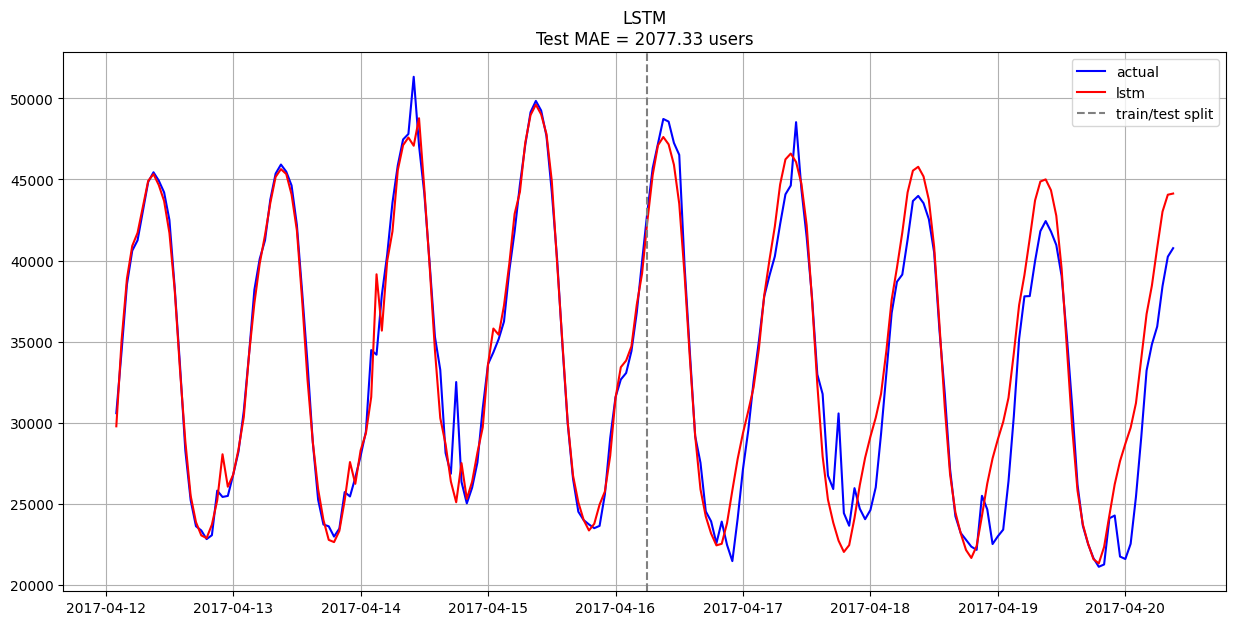

In [109]:
actual_last_200 = data["Users"].iloc[-200:]
pred_last_200 = pd.concat([train_pred_tail, forecast_100])

plt.figure(figsize=(15, 7))
plt.plot(actual_last_200.index, actual_last_200.values, label="actual", color="blue")
plt.plot(pred_last_200.index, pred_last_200.values, label="lstm", color="red")
plt.axvline(data.index[train_size], color="gray", linestyle="--", label="train/test split")
plt.title(f"LSTM\nTest MAE = {mae_test:.2f} users")
plt.legend()
plt.grid(True)
plt.show()